# Анализ признаков model и mark

Цель: оценить качество и полезность признаков `model` и `mark` на уровне полиса (contract-level) и проверить их согласованность (модель ↔ марка).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

In [2]:
DATA_PATH = "dataset/train.csv"
COL_MARK = "mark"
COL_MODEL = "model"

df = pd.read_csv(DATA_PATH)
df[[COL_MARK, COL_MODEL]].head()

/tmp/ipykernel_461198/2266231335.py:5: DtypeWarning: Columns (0: bonus_malus, 1: car_year) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


,mark,model
0,HYUNDAI,SONATA
1,LADA,21703 138 31
2,INFINITI,QX 80
3,TOYOTA,CAMRY
4,BMW,X5


In [3]:
# Подготовка строковых значений и пары mark-model
def _safe_str(value) -> str:
    if value is None or pd.isna(value):
        return "MISSING"
    return str(value).strip()

df["mark_clean"] = df[COL_MARK].apply(_safe_str)
df["model_clean"] = df[COL_MODEL].apply(_safe_str)
df["mark_model_pair"] = df["mark_clean"] + "||" + df["model_clean"]

df[["mark_clean", "model_clean", "mark_model_pair"]].head()

/tmp/ipykernel_461198/3412111684.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["mark_clean"] = df[COL_MARK].apply(_safe_str)
/tmp/ipykernel_461198/3412111684.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["model_clean"] = df[COL_MODEL].apply(_safe_str)
/tmp/ipykernel_461198/3412111684.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a

,mark_clean,model_clean,mark_model_pair
0,HYUNDAI,SONATA,HYUNDAI||SONATA
1,LADA,21703 138 31,LADA||21703 138 31
2,INFINITI,QX 80,INFINITI||QX 80
3,TOYOTA,CAMRY,TOYOTA||CAMRY
4,BMW,X5,BMW||X5


In [4]:
# Агрегируем до уровня полиса, чтобы избежать искусственного увеличения выборки
def _mode_or_multi(series: pd.Series) -> str:
    values = series.dropna()
    if values.empty:
        return np.nan
    uniq = values.unique()
    if len(uniq) == 1:
        return uniq[0]
    return "MULTI"

df_contract = (
    df.groupby("contract_number", as_index=False)
    .agg(
        mark_contract=("mark_clean", _mode_or_multi),
        model_contract=("model_clean", _mode_or_multi),
        mark_model_pair=("mark_model_pair", _mode_or_multi),
        premium=("premium", "first"),
        premium_wo_term=("premium_wo_term", "first"),
        claim_amount=("claim_amount", "first"),
        claim_cnt=("claim_cnt", "first"),
        is_claim=("is_claim", "first"),
    )
)

df_contract.head()

,contract_number,mark_contract,model_contract,mark_model_pair,premium,premium_wo_term,claim_amount,claim_cnt,is_claim
0,000153ebe13e6fff0f59b2977d403c82ca2a97f3133d96...,LEXUS,RX 350,LEXUS||RX 350,16195.0,16195.0,NaN,NaN,0
1,0001a1cb0431d08f3ccb0a5ec65349678dad2266de183d...,TOYOTA,CAMRY,TOYOTA||CAMRY,14289.0,14289.0,NaN,NaN,0
2,0001e313d188345c3faa257552bd4287469bf7268229e0...,KIA,RIO,KIA||RIO,7249.0,7249.0,NaN,NaN,0
3,0001e54c51ced85c85e97021b85639040db9301adc151e...,MAZDA,626,MAZDA||626,6483.0,6483.0,NaN,NaN,0
4,0001ecb71a613337bd5264c47e8383d56b5428994b94fd...,SUBARU,MULTI,MULTI,5949.0,291.0,NaN,NaN,0


In [5]:
# Проверка согласованности model ↔ mark на уровне строк (driver-level)
map_df = df[["mark_clean", "model_clean"]].copy()

models_per_mark = map_df.groupby("mark_clean")["model_clean"].nunique().sort_values(ascending=False)
marks_per_model = map_df.groupby("model_clean")["mark_clean"].nunique().sort_values(ascending=False)

print("Уникальных моделей на одну марку (топ-10):")
display(models_per_mark.head(10))
print("Уникальных марок на одну модель (топ-10):")
display(marks_per_model.head(10))

multi_mark_for_model = marks_per_model[marks_per_model > 1]
print(f"Доля моделей с более чем одной маркой: {len(multi_mark_for_model) / len(marks_per_model):.4f}")

multi_share_mark = (df_contract["mark_contract"] == "MULTI").mean()
multi_share_model = (df_contract["model_contract"] == "MULTI").mean()
multi_share_pair = (df_contract["mark_model_pair"] == "MULTI").mean()
print(f"Доля полисов с MULTI в mark: {multi_share_mark:.4f}")
print(f"Доля полисов с MULTI в model: {multi_share_model:.4f}")
print(f"Доля полисов с MULTI в mark_model_pair: {multi_share_pair:.4f}")

Уникальных моделей на одну марку (топ-10):


mark_clean
MERCEDES-BENZ    948
ГАЗ              769
LADA             708
TOYOTA           582
ВАЗ              499
ЛАДА             381
HYUNDAI          368
NISSAN           331
MERCEDES         321
BMW              319
Name: model_clean, dtype: int64

Уникальных марок на одну модель (топ-10):


model_clean
2715 01 14     25
NEXIA          12
CAMRY          10
ПРИЦЕП         10
ACCENT          9
200             8
SPRINTER        7
SX3251DM384     7
100             5
821303          5
Name: mark_clean, dtype: int64

Доля моделей с более чем одной маркой: 0.0843
Доля полисов с MULTI в mark: 0.0628
Доля полисов с MULTI в model: 0.0676
Доля полисов с MULTI в mark_model_pair: 0.0676


Доля пропусков mark: 0.0000
Доля пропусков model: 0.0000
Доля пропусков mark_model_pair: 0.0000
Кардинальность mark: 1185
Кардинальность model: 9379
Кардинальность mark_model_pair: 10454


mark_contract
TOYOTA           32910
HYUNDAI          13486
MULTI            11337
VOLKSWAGEN       10626
MERCEDES-BENZ     8420
LADA              8202
KIA               7492
NISSAN            7197
CHEVROLET         7062
AUDI              6875
ВАЗ               6748
MITSUBISHI        6617
LEXUS             5685
DAEWOO            5149
BMW               4190
ГАЗ               3878
OPEL              3501
MAZDA             3255
SUBARU            2992
HONDA             2346
Name: count, dtype: int64

model_contract
CAMRY                 13257
MULTI                 12212
NEXIA                  3961
ACCENT                 3883
PASSAT                 3583
COBALT                 2987
RIO                    2676
COROLLA                2408
100                    2191
GOLF                   2182
VECTRA                 2103
ELANTRA                1910
RAV4                   1656
626                    1583
POLO                   1463
LAND CRUISER PRADO     1459
TUCSON                 1452
SONATA                 1333
HIGHLANDER             1270
80                     1190
Name: count, dtype: int64

mark_model_pair
TOYOTA||CAMRY                 13246
MULTI                         12219
HYUNDAI||ACCENT                3871
VOLKSWAGEN||PASSAT             3574
CHEVROLET||COBALT              2982
KIA||RIO                       2672
DAEWOO||NEXIA                  2483
TOYOTA||COROLLA                2405
AUDI||100                      2188
VOLKSWAGEN||GOLF               2181
OPEL||VECTRA                   2103
HYUNDAI||ELANTRA               1906
TOYOTA||RAV4                   1656
MAZDA||626                     1583
CHEVROLET||NEXIA               1463
TOYOTA||LAND CRUISER PRADO     1459
VOLKSWAGEN||POLO               1458
HYUNDAI||TUCSON                1448
HYUNDAI||SONATA                1327
TOYOTA||HIGHLANDER             1270
Name: count, dtype: int64

count     1185.000000
mean       152.434599
std       1318.793390
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
90%         16.000000
95%        101.800000
max      32910.000000
Name: count, dtype: float64

count     9379.000000
mean        19.259516
std        220.769996
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
90%         14.000000
95%         38.000000
max      13257.000000
Name: count, dtype: float64

count    10454.000000
mean        17.279032
std        207.151571
min          1.000000
25%          1.000000
50%          1.000000
75%          4.000000
90%         13.000000
95%         32.000000
max      13246.000000
Name: count, dtype: float64

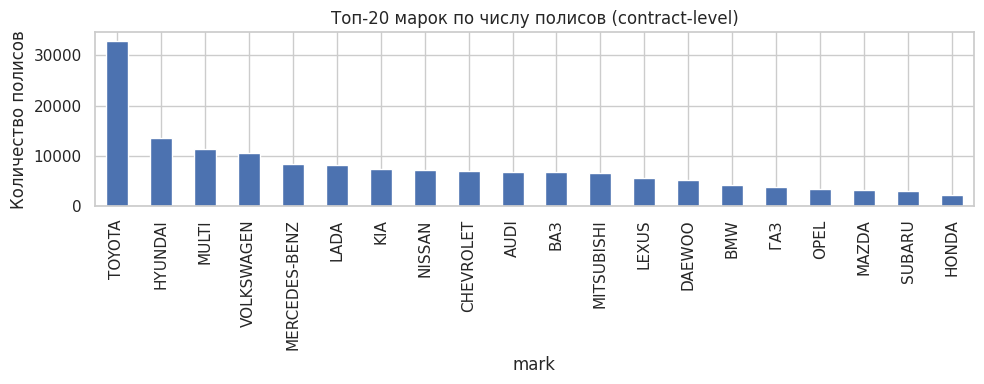

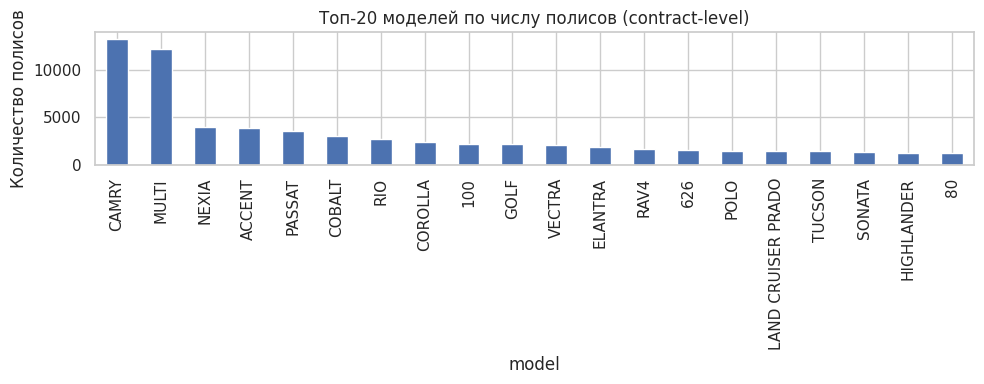

In [6]:
# Дистрибуция, пропуски, кардинальность (contract-level)
missing_mark = df_contract["mark_contract"].isna().mean()
missing_model = df_contract["model_contract"].isna().mean()
missing_pair = df_contract["mark_model_pair"].isna().mean()

card_mark = df_contract["mark_contract"].nunique(dropna=True)
card_model = df_contract["model_contract"].nunique(dropna=True)
card_pair = df_contract["mark_model_pair"].nunique(dropna=True)

print(f"Доля пропусков mark: {missing_mark:.4f}")
print(f"Доля пропусков model: {missing_model:.4f}")
print(f"Доля пропусков mark_model_pair: {missing_pair:.4f}")
print(f"Кардинальность mark: {card_mark}")
print(f"Кардинальность model: {card_model}")
print(f"Кардинальность mark_model_pair: {card_pair}")

mark_counts = df_contract["mark_contract"].value_counts(dropna=False)
model_counts = df_contract["model_contract"].value_counts(dropna=False)
pair_counts = df_contract["mark_model_pair"].value_counts(dropna=False)

display(mark_counts.head(20))
display(model_counts.head(20))
display(pair_counts.head(20))

display(mark_counts.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]))
display(model_counts.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]))
display(pair_counts.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]))

plt.figure(figsize=(10, 4))
mark_counts.head(20).plot(kind="bar")
plt.title("Топ-20 марок по числу полисов (contract-level)")
plt.xlabel("mark")
plt.ylabel("Количество полисов")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
model_counts.head(20).plot(kind="bar")
plt.title("Топ-20 моделей по числу полисов (contract-level)")
plt.xlabel("model")
plt.ylabel("Количество полисов")
plt.tight_layout()
plt.show()

In [7]:
# Корреляции с таргетами (категориальный признак кодируем порядково)
def categorical_correlations(data: pd.DataFrame, feature: str) -> pd.DataFrame:
    codes = data[feature].astype("category").cat.codes
    rows = []
    for target in ["is_claim", "claim_amount"]:
        pearson = codes.corr(data[target], method="pearson")
        spearman = codes.corr(data[target], method="spearman")
        rows.append({"feature": feature, "target": target, "pearson": pearson, "spearman": spearman})
    return pd.DataFrame(rows)

corr_table = pd.concat(
    [
        categorical_correlations(df_contract, "mark_contract"),
        categorical_correlations(df_contract, "model_contract"),
        categorical_correlations(df_contract, "mark_model_pair"),
    ],
    ignore_index=True,
)
display(corr_table)

# Дополнительно: частота выплат по маркам/моделям
mark_claim_rate = df_contract.groupby("mark_contract")["is_claim"].mean().sort_values(ascending=False)
model_claim_rate = df_contract.groupby("model_contract")["is_claim"].mean().sort_values(ascending=False)

display(mark_claim_rate.head(20))
display(model_claim_rate.head(20))

,feature,target,pearson,spearman
0,mark_contract,is_claim,-0.011412,-0.011893
1,mark_contract,claim_amount,0.007046,0.031318
2,model_contract,is_claim,0.004738,0.004276
3,model_contract,claim_amount,-0.018774,-0.021627
4,mark_model_pair,is_claim,-0.011929,-0.011574
5,mark_model_pair,claim_amount,0.009302,0.029259


mark_contract
ЛУИДОР                    1.000000
SUBARU   FORESTER         1.000000
HYUNDAI   SOLARIS         1.000000
STEYR                     1.000000
TAYOTA CAMRY              1.000000
DONGFENG-EQ1040N14D3AC    1.000000
TOYOTA СОRJLLA            1.000000
LADA 21902 111 41         1.000000
DATSUN-MI-DO              1.000000
ГАЗ-27527-753             1.000000
CEVROLET                  0.500000
ВАЗ-21101                 0.500000
МЕРСЕДЕС                  0.500000
LIFAN-X60                 0.333333
DAEVOO                    0.333333
ВАЗ211440                 0.333333
ВАЗ-21102                 0.250000
ГАЗ-A31R33-20             0.250000
LADA 21901-010 -41        0.250000
ГАЗЕЛЬ                    0.200000
Name: is_claim, dtype: float64

model_contract
GRAND                        1.0
С 4                          1.0
X-TRAIL 2 0 CVT 4 WD XE      1.0
B170                         1.0
J  GE 6                      1.0
J CA                         1.0
33028-288                    1.0
21906-110-40                 1.0
CHRYSLER  D  203             1.0
JUKE 1 6 CVT 2WD SE SPORT    1.0
YETI ACTIVE PACK 3           1.0
BENZ 1422                    1.0
DONGFENG-EQ1040N14D3AC       1.0
VOLT                         1.0
KLAN 200 LACETT              1.0
- MYWAY                      1.0
PRIMERA P11                  1.0
219470                       1.0
VESTA GFL 13-Y00-52          1.0
CAYENNE PLATINUM EDITION     1.0
Name: is_claim, dtype: float64

In [8]:
# WoE/IV для категориальных признаков с укрупнением редких категорий
def collapse_rare(data: pd.DataFrame, feature: str, min_count: int = 50) -> pd.Series:
    counts = data[feature].value_counts(dropna=False)
    rare_values = counts[counts < min_count].index
    collapsed = data[feature].where(~data[feature].isin(rare_values), "RARE")
    return collapsed

def woe_iv_categorical(data: pd.DataFrame, feature: str, target: str) -> tuple[pd.DataFrame, float]:
    df_tmp = data[[feature, target]].copy()
    df_tmp[feature] = df_tmp[feature].astype(str).fillna("MISSING")

    total_good = (df_tmp[target] == 0).sum()
    total_bad = (df_tmp[target] == 1).sum()

    agg = (
        df_tmp.groupby(feature)[target]
        .agg(["count", "sum"])
        .rename(columns={"sum": "bad"})
    )
    agg["good"] = agg["count"] - agg["bad"]

    # Сглаживание, чтобы избежать деления на ноль
    agg["bad_rate"] = (agg["bad"] + 0.5) / (total_bad + 1.0)
    agg["good_rate"] = (agg["good"] + 0.5) / (total_good + 1.0)
    agg["woe"] = np.log(agg["good_rate"] / agg["bad_rate"])
    agg["iv"] = (agg["good_rate"] - agg["bad_rate"]) * agg["woe"]

    iv_total = agg["iv"].sum()
    return agg.sort_values("iv", ascending=False), iv_total

df_contract["mark_contract_woe"] = collapse_rare(df_contract, "mark_contract", min_count=50)
df_contract["model_contract_woe"] = collapse_rare(df_contract, "model_contract", min_count=50)
df_contract["mark_model_pair_woe"] = collapse_rare(df_contract, "mark_model_pair", min_count=50)

woe_mark, iv_mark = woe_iv_categorical(df_contract, "mark_contract_woe", "is_claim")
woe_model, iv_model = woe_iv_categorical(df_contract, "model_contract_woe", "is_claim")
woe_pair, iv_pair = woe_iv_categorical(df_contract, "mark_model_pair_woe", "is_claim")

display(woe_mark.head(20))
print(f"IV (mark): {iv_mark:.6f}")
display(woe_model.head(20))
print(f"IV (model): {iv_model:.6f}")
display(woe_pair.head(20))
print(f"IV (mark_model_pair): {iv_pair:.6f}")

,count,bad,good,bad_rate,good_rate,woe,iv
mark_contract_woe,,,,,,,
CHEVROLET,7062,233,6829,0.065296,0.038571,-0.526425,0.014069
MULTI,11337,146,11191,0.040968,0.063207,0.433635,0.009644
FORD,1121,4,1117,0.001258,0.006311,1.612522,0.008148
ВАЗ,6748,87,6661,0.024469,0.037623,0.430212,0.005659
SCHMITZ,344,0,344,0.000140,0.001946,2.632992,0.004755
УАЗ,657,3,654,0.000979,0.003696,1.328859,0.003611
HYUNDAI,13486,323,13163,0.090464,0.074344,-0.196245,0.003163
КАМАЗ,482,2,480,0.000699,0.002714,1.356287,0.002732
ПРИЦЕП,214,0,214,0.000140,0.001211,2.159207,0.002314


IV (mark): 0.080269


,count,bad,good,bad_rate,good_rate,woe,iv
model_contract_woe,,,,,,,
MULTI,12212,159,12053,0.044603,0.068075,0.422817,0.009925
COBALT,2987,105,2882,0.029502,0.016280,-0.594547,0.007861
NEXIA,3961,116,3845,0.032578,0.021719,-0.405482,0.004403
100,2191,22,2169,0.006292,0.012253,0.666487,0.003973
ACCENT,3883,108,3775,0.030341,0.021323,-0.352712,0.003181
TRANSIT,406,1,405,0.000419,0.002290,1.697406,0.003175
21214,369,1,368,0.000419,0.002081,1.601726,0.002662
80 B4,113,8,105,0.002377,0.000596,-1.383605,0.002464
CRUZE,700,26,674,0.007411,0.003809,-0.665423,0.002396


IV (model): 0.161692


,count,bad,good,bad_rate,good_rate,woe,iv
mark_model_pair_woe,,,,,,,
MULTI,12219,159,12060,0.044603,0.068115,0.423398,0.009955
CHEVROLET||NEXIA,1463,63,1400,0.017757,0.007910,-0.808705,0.007964
CHEVROLET||COBALT,2982,105,2877,0.029502,0.016251,-0.596283,0.007901
AUDI||100,2188,22,2166,0.006292,0.012236,0.665103,0.003953
HYUNDAI||ACCENT,3871,108,3763,0.030341,0.021255,-0.355895,0.003234
FORD||TRANSIT,405,1,404,0.000419,0.002285,1.694937,0.003161
AUDI||80 B4,113,8,105,0.002377,0.000596,-1.383605,0.002464
HYUNDAI||SONATA,1327,42,1285,0.011885,0.007260,-0.492850,0.002279
CHEVROLET||CRUZE,697,25,672,0.007131,0.003798,-0.629926,0.002099


IV (mark_model_pair): 0.166642


Loss ratio overall: 1.233424
Топ-20 mark по loss ratio:


mark_contract
HYUNDAI   SOLARIS         134.343368
SUBARU   FORESTER         123.211892
ГАЗ-A31R33-20              49.698687
ГАЗ-27527-753              42.442547
ВАЗ-21102                  42.182055
TAYOTA CAMRY               33.344914
DATSUN-MI-DO               21.561881
LADA 21901-010 -41         20.443114
ГАЗ-322131-95              18.360665
SCHWARZMUELLER             16.342639
LADA21942                  12.868951
ВАЗ-21101                  11.219312
DAEVOO                      9.583735
ГАЗЕЛЬ                      9.295043
ВАЗ211440                   7.965563
ГАЗ-330252                  7.382009
ACURA                       7.183927
ЛУИДОР                      6.900505
DONGFENG                    6.212387
DONGFENG-EQ1040N14D3AC      5.871518
dtype: float64

Топ-20 model по loss ratio:


model_contract
C230K                        760.993789
AVENSIS 2 0 CVT              580.645161
USA  GS                      338.453039
217050 PRIORA                234.387640
LARGUS CROSS                 205.846774
3221-95                      200.000000
320232                       169.231504
SX3254DM384                  155.713986
200 TE                       149.853229
VESTA GFL 13-Y00-52          141.182777
BENZ 1422                    140.162197
J CA                         138.572264
JUKE 1 6 CVT 2WD SE SPORT    137.374794
BJ1069VCJEA-D                134.391225
HYUNDAI   SOLARIS            134.343368
CAYENNE PLATINUM EDITION     134.119964
NEXIA DOHC 150GLE            134.065189
GRANTA 21901                 128.499365
X4 XDRIVE 30I                126.147782
SUBARU   FORESTER            123.211892
dtype: float64

Топ-20 mark_model_pair по loss ratio:


mark_model_pair
MERCEDES-BENZ||C230K                    760.993789
TOYOTA||AVENSIS 2 0 CVT                 580.645161
CHRYSLER||USA  GS                       338.453039
SHACMAN||SX3254DM384                    249.790483
LADA||217050 PRIORA                     234.387640
LADA||LARGUS CROSS                      205.846774
ГАЗ||3221-95                            200.000000
ГАЗ||320232                             169.231504
MERCEDES-BENZ||200 TE                   149.853229
LADA||VESTA GFL 13-Y00-52               141.182777
DAIMLER||BENZ 1422                      140.162197
MAZDA||J CA                             138.572264
NISSAN||JUKE 1 6 CVT 2WD SE SPORT       137.374794
FOTON||BJ1069VCJEA-D                    134.391225
HYUNDAI   SOLARIS||HYUNDAI   SOLARIS    134.343368
PORSCHE||CAYENNE PLATINUM EDITION       134.119964
DAEWOO||NEXIA DOHC 150GLE               134.065189
LADA||GRANTA 21901                      128.499365
BMW||X4 XDRIVE 30I                      126.147782
SUBARU   FOREST

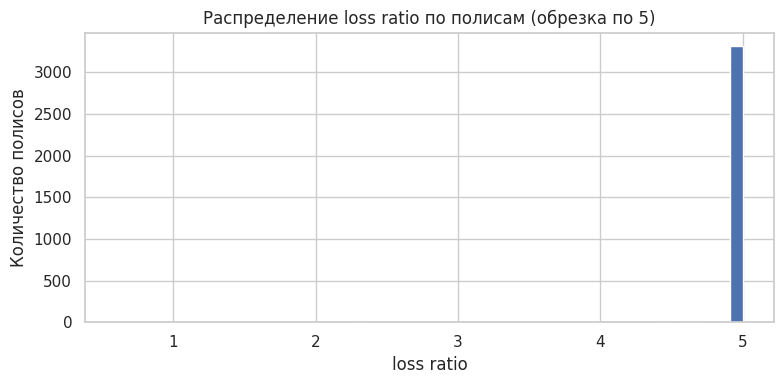

In [10]:
# Loss ratio и связанные метрики (contract-level)

def safe_loss_ratio(claim_sum: float, premium_sum: float) -> float:
    if premium_sum and premium_sum > 0:
        return claim_sum / premium_sum
    return np.nan

# Общий loss ratio по портфелю
premium_sum_all = df_contract["premium_wo_term"].sum()
claim_sum_all = df_contract["claim_amount"].sum()
overall_lr = safe_loss_ratio(claim_sum_all, premium_sum_all)

print(f"Loss ratio overall: {overall_lr:.6f}")

# Loss ratio по маркам/моделям/парам
mark_lr = (
    df_contract.groupby("mark_contract")
    .apply(lambda g: safe_loss_ratio(g["claim_amount"].sum(), g["premium_wo_term"].sum()))
    .sort_values(ascending=False)
)

model_lr = (
    df_contract.groupby("model_contract")
    .apply(lambda g: safe_loss_ratio(g["claim_amount"].sum(), g["premium_wo_term"].sum()))
    .sort_values(ascending=False)
)

pair_lr = (
    df_contract.groupby("mark_model_pair")
    .apply(lambda g: safe_loss_ratio(g["claim_amount"].sum(), g["premium_wo_term"].sum()))
    .sort_values(ascending=False)
)

print("Топ-20 mark по loss ratio:")
display(mark_lr.head(20))
print("Топ-20 model по loss ratio:")
display(model_lr.head(20))
print("Топ-20 mark_model_pair по loss ratio:")
display(pair_lr.head(20))

# Распределение loss ratio по полисам
loss_ratio_series = df_contract.apply(
    lambda row: safe_loss_ratio(row["claim_amount"], row["premium_wo_term"]), axis=1
)

plt.figure(figsize=(8, 4))
loss_ratio_series.clip(upper=5).hist(bins=50)
plt.title("Распределение loss ratio по полисам (обрезка по 5)")
plt.xlabel("loss ratio")
plt.ylabel("Количество полисов")
plt.tight_layout()
plt.show()

In [11]:
# Короткий summary-вывод для быстрой интерпретации

summary_rows = []

for feature in ["mark_contract", "model_contract", "mark_model_pair"]:
    summary_rows.append({
        "feature": feature,
        "missing_rate": df_contract[feature].isna().mean(),
        "cardinality": df_contract[feature].nunique(dropna=True),
        "multi_share": (df_contract[feature] == "MULTI").mean(),
    })

summary_df = pd.DataFrame(summary_rows)
print("=== Summary по признакам ===")
display(summary_df)

print("=== Correlations ===")
display(corr_table)

print("=== IV ===")
print(f"IV mark: {iv_mark:.6f}")
print(f"IV model: {iv_model:.6f}")
print(f"IV mark_model_pair: {iv_pair:.6f}")

print("=== Loss ratio overall ===")
print(f"LR overall: {overall_lr:.6f}")

print("=== Leakage-check (count>=50) ===")
print("mark:")
display(leak_mark.head(10))
print("model:")
display(leak_model.head(10))
print("pair:")
display(leak_pair.head(10))

=== Summary по признакам ===


,feature,missing_rate,cardinality,multi_share
0,mark_contract,0.0,1185,0.062762
1,model_contract,0.0,9379,0.067606
2,mark_model_pair,0.0,10454,0.067645


=== Correlations ===


,feature,target,pearson,spearman
0,mark_contract,is_claim,-0.011412,-0.011893
1,mark_contract,claim_amount,0.007046,0.031318
2,model_contract,is_claim,0.004738,0.004276
3,model_contract,claim_amount,-0.018774,-0.021627
4,mark_model_pair,is_claim,-0.011929,-0.011574
5,mark_model_pair,claim_amount,0.009302,0.029259


=== IV ===
IV mark: 0.080269
IV model: 0.161692
IV mark_model_pair: 0.166642
=== Loss ratio overall ===
LR overall: 1.233424
=== Leakage-check (count>=50) ===
mark:


,mean,count
mark_contract,,
SCHMITZ,0.0,344
ПРИЦЕП,0.0,214
LAND,0.0,114
ISUZU,0.0,85
TESLA,0.0,70
EXEED,0.0,64
CHANGAN,0.0,58
IVECO,0.0,52
ГКБ,0.0,51


model:


,mean,count
model_contract,,
FOCUS,0.0,183
728,0.0,128
21065,0.0,121
GOLF III,0.0,117
SHUTTLE,0.0,115
525I,0.0,113
ES 250,0.0,112
240 E,0.0,101
CHARIOT,0.0,97


pair:


,mean,count
mark_model_pair,,
FORD||FOCUS,0.0,182
LADA||21703,0.0,138
BMW||728,0.0,128
ВАЗ||21065,0.0,120
MERCEDES-BENZ||320,0.0,119
VOLKSWAGEN||GOLF III,0.0,117
HONDA||SHUTTLE,0.0,115
BMW||525I,0.0,113
DAEWOO||DAMAS,0.0,112


In [ ]:
# Короткий summary-вывод для быстрой интерпретации

summary_rows = []

for feature in ["mark_contract", "model_contract", "mark_model_pair"]:
    summary_rows.append({
        "feature": feature,
        "missing_rate": df_contract[feature].isna().mean(),
        "cardinality": df_contract[feature].nunique(dropna=True),
        "multi_share": (df_contract[feature] == "MULTI").mean(),
    })

summary_df = pd.DataFrame(summary_rows)
print("=== Summary по признакам ===")
display(summary_df)

print("=== Correlations ===")
display(corr_table)

print("=== IV ===")
print(f"IV mark: {iv_mark:.6f}")
print(f"IV model: {iv_model:.6f}")
print(f"IV mark_model_pair: {iv_pair:.6f}")

print("=== Loss ratio overall ===")
print(f"LR overall: {overall_lr:.6f}")

print("=== Leakage-check (count>=50) ===")
print("mark:")
display(leak_mark.head(10))
print("model:")
display(leak_model.head(10))
print("pair:")
display(leak_pair.head(10))

=== Summary по признакам ===


,feature,missing_rate,cardinality,multi_share
0,mark_contract,0.0,1185,0.062762
1,model_contract,0.0,9379,0.067606
2,mark_model_pair,0.0,10454,0.067645


=== Correlations ===


,feature,target,pearson,spearman
0,mark_contract,is_claim,-0.011412,-0.011893
1,mark_contract,claim_amount,0.007046,0.031318
2,model_contract,is_claim,0.004738,0.004276
3,model_contract,claim_amount,-0.018774,-0.021627
4,mark_model_pair,is_claim,-0.011929,-0.011574
5,mark_model_pair,claim_amount,0.009302,0.029259


=== IV ===
IV mark: 0.080269
IV model: 0.161692
IV mark_model_pair: 0.166642
=== Loss ratio overall ===
LR overall: 1.233424
=== Leakage-check (count>=50) ===
mark:


,mean,count
mark_contract,,
SCHMITZ,0.0,344
ПРИЦЕП,0.0,214
LAND,0.0,114
ISUZU,0.0,85
TESLA,0.0,70
EXEED,0.0,64
CHANGAN,0.0,58
IVECO,0.0,52
ГКБ,0.0,51


model:


,mean,count
model_contract,,
FOCUS,0.0,183
728,0.0,128
21065,0.0,121
GOLF III,0.0,117
SHUTTLE,0.0,115
525I,0.0,113
ES 250,0.0,112
240 E,0.0,101
CHARIOT,0.0,97


pair:


,mean,count
mark_model_pair,,
FORD||FOCUS,0.0,182
LADA||21703,0.0,138
BMW||728,0.0,128
ВАЗ||21065,0.0,120
MERCEDES-BENZ||320,0.0,119
VOLKSWAGEN||GOLF III,0.0,117
HONDA||SHUTTLE,0.0,115
BMW||525I,0.0,113
DAEWOO||DAMAS,0.0,112


In [9]:
# Leakage-check: категории с 100% выплатами или 0% выплат при заметной численности
def leakage_check(data: pd.DataFrame, feature: str, min_count: int = 50) -> pd.DataFrame:
    stats = (
        data.groupby(feature)["is_claim"]
        .agg(["mean", "count"])
        .sort_values("count", ascending=False)
    )
    return stats[(stats["count"] >= min_count) & ((stats["mean"] == 1.0) | (stats["mean"] == 0.0))]

leak_mark = leakage_check(df_contract, "mark_contract", min_count=50)
leak_model = leakage_check(df_contract, "model_contract", min_count=50)
leak_pair = leakage_check(df_contract, "mark_model_pair", min_count=50)
display(leak_mark.head(20))
display(leak_model.head(20))
display(leak_pair.head(20))

print("Если есть категории с mean=1 или mean=0 и достаточным count, возможен leakage или артефакт сегментации.")

,mean,count
mark_contract,,
SCHMITZ,0.0,344
ПРИЦЕП,0.0,214
LAND,0.0,114
ISUZU,0.0,85
TESLA,0.0,70
EXEED,0.0,64
CHANGAN,0.0,58
IVECO,0.0,52
ГКБ,0.0,51


,mean,count
model_contract,,
FOCUS,0.0,183
728,0.0,128
21065,0.0,121
GOLF III,0.0,117
SHUTTLE,0.0,115
525I,0.0,113
ES 250,0.0,112
240 E,0.0,101
CHARIOT,0.0,97


,mean,count
mark_model_pair,,
FORD||FOCUS,0.0,182
LADA||21703,0.0,138
BMW||728,0.0,128
ВАЗ||21065,0.0,120
MERCEDES-BENZ||320,0.0,119
VOLKSWAGEN||GOLF III,0.0,117
HONDA||SHUTTLE,0.0,115
BMW||525I,0.0,113
DAEWOO||DAMAS,0.0,112


Если есть категории с mean=1 или mean=0 и достаточным count, возможен leakage или артефакт сегментации.


## Итоги

**Summary** — После агрегации на уровне полиса `model` и особенно связка `mark_model_pair` дают измеримый, но не сильный сигнал; общий $loss\_ratio\approx 1.23$ существенно выше целевых $0.7$, поэтому признак полезен для сегментации и repricing, но требует укрупнения редких категорий.

**Correlations** — Связи слабые: для `is_claim` Pearson около $[-0.012; 0.005]$, Spearman около $[-0.012; 0.004]$. Для `claim_amount` Spearman $\approx 0.031$ у `mark` и $\approx 0.029$ у `pair`, у `model` отрицательная слабая связь ($\approx -0.022$). Эффект сохраняется на contract-level, но остаётся слабым.

**Feature quality** — IV: `mark` = 0.080 (слабый сигнал), `model` = 0.162 (средний), `mark_model_pair` = 0.167 (средний). Пропусков нет (0.0). Кардинальность высокая: 1185 / 9379 / 10454. Leakage: possible — есть нулевые категории при count≥50 (например, ряд марок/моделей/пар с mean=0).

**Business impact** — По отдельным маркам/моделям возможна локальная переразметка (repricing) и выявление low-risk сегментов, но в целом признак не “объясняет” высокий портфельный $loss\_ratio$; основная ценность — в построении стабильных бинов и risk-tier по брендам/моделям.

**Engineering ideas** — `mark_model_pair` как базовый признак после укрупнения редких значений в `RARE`; `brand_risk_tier` и `model_risk_tier` на основе $loss\_ratio$ по группам; `is_multi_model_in_policy` как индикатор неоднозначности; нормализовать строки (`upper`, удаление пробелов/двойных пробелов, унификация транслита).

**Caveats** — Очень высокая кардинальность и редкие категории искажают WoE/IV; `MULTI` в полисе ухудшает интерпретацию; возможны опечатки и вариативность написания, что дробит группы.

**Next steps** — 1) Пересчитать IV при разных `min_count` для `RARE`. 2) Сравнить стабильность $loss\_ratio$ по брендам/моделям на временных сплитах. 3) Проверить выигрыш модели при замене `model` на `mark_model_pair` с укрупнением.